## Importing Libraries

In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')


## Load and Inspect Data


In [2]:
# Load data
df = pd.read_csv('marketing_AB.csv')

# Inspect Data
df.head()


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
# Drop non-analytic identifier columns
df.drop(columns=['Unnamed: 0', 'user id'], inplace=True)

# Display first rows
df.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


## Exploratory Data Analysis

In [4]:
# Basic shape and info
print("Shape:", df.shape)
print(df.info())

# Summary stats for numeric columns
df.describe().T


Shape: (588101, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   test group     588101 non-null  object
 1   converted      588101 non-null  bool  
 2   total ads      588101 non-null  int64 
 3   most ads day   588101 non-null  object
 4   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(2), object(2)
memory usage: 18.5+ MB
None


,count,mean,std,min,25%,50%,75%,max
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


In [5]:
# Unique values
print("Test group:", df['test group'].unique())
print("Converted:", df['converted'].unique())
print("Most ads day:", df['most ads day'].unique())


Test group: ['ad' 'psa']
Converted: [False  True]
Most ads day: ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']


## Data Preprocessing


In [6]:
df['converted']

0         False
1         False
2         False
3         False
4         False
          ...  
588096    False
588097    False
588098    False
588099    False
588100    False
Name: converted, Length: 588101, dtype: bool

In [7]:
# Convert boolean flag to 0/1 for numeric analysis
df['converted'] = df['converted'].astype(int)

df.dtypes

test group       object
converted         int64
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

In [8]:
df['converted']

0         0
1         0
2         0
3         0
4         0
         ..
588096    0
588097    0
588098    0
588099    0
588100    0
Name: converted, Length: 588101, dtype: int64

## Data Visulization


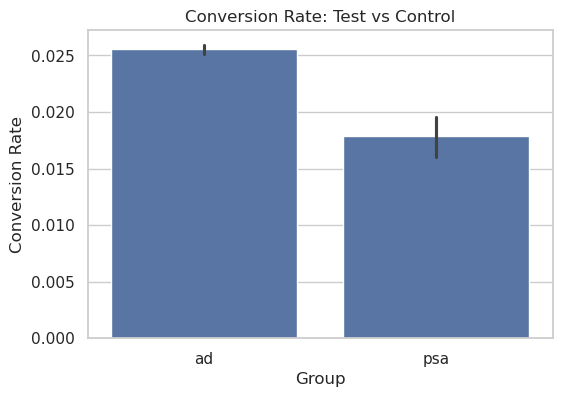

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='test group', y='converted')
plt.title("Conversion Rate: Test vs Control")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

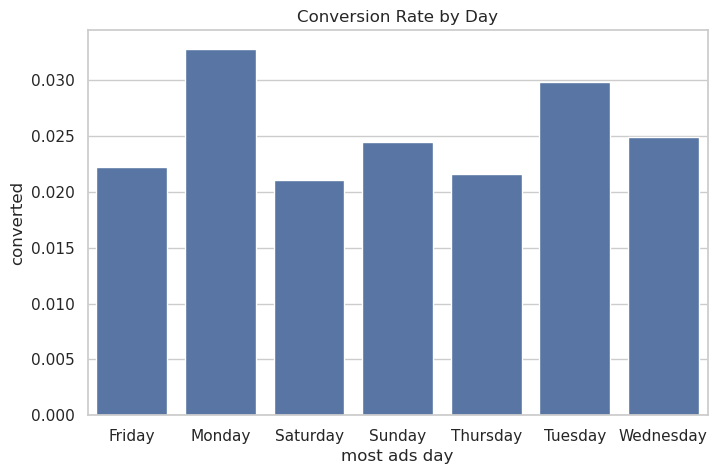

In [10]:
day_cr = df.groupby('most ads day')['converted'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=day_cr, x='most ads day', y='converted')
plt.title("Conversion Rate by Day")
plt.show()


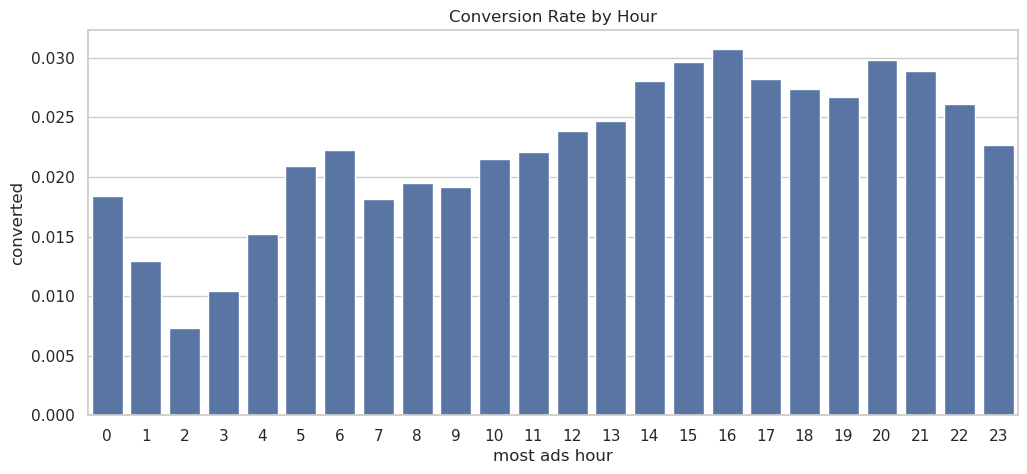

In [11]:
hour_cr = df.groupby('most ads hour')['converted'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=hour_cr, x='most ads hour', y='converted')
plt.title("Conversion Rate by Hour")
plt.show()


## Statistical Testings

### A/B Test — Compare Conversion Rates

In [12]:
# Split into control (PSA) and treatment (Ad) cohorts
control_grp = df[df['test group'] == 'psa']
treatment_grp = df[df['test group'] == 'ad']

ctrl_conv = control_grp['converted']
trt_conv = treatment_grp['converted']

t_statistic, p_value = stats.ttest_ind(trt_conv, ctrl_conv)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 → statistically significant difference in conversion rates")
else:
    print("Result: Fail to reject H0 → no statistically significant difference")


t-statistic: 7.37040597428566
p-value: 1.7033052627831264e-13
Result: Reject H0 → statistically significant difference in conversion rates


### ANOVA — Does day of most ads affect conversion?

In [13]:
# ANOVA across day-of-week groups
anova_by_day = stats.f_oneway(*[
    df[df['most ads day'] == day_name]['converted']
    for day_name in df['most ads day'].unique()
])

print("ANOVA — Most Ads Day")
print("F-statistic:", anova_by_day.statistic)
print("p-value:", anova_by_day.pvalue)

if anova_by_day.pvalue < 0.05:
    print("Result: Reject H0 → day significantly affects conversion.")
else:
    print("Result: Fail to reject H0 → no detectable day effect.")


ANOVA — Most Ads Day
F-statistic: 68.38818386898068
p-value: 1.8032007655359558e-85
Result: Reject H0 → day significantly affects conversion.


## ANOVA — Does hour with most ads affect conversion?

In [14]:
# ANOVA across hour-of-day groups
anova_by_hour = stats.f_oneway(*[
    df[df['most ads hour'] == hour]['converted']
    for hour in sorted(df['most ads hour'].unique())
])

print("ANOVA — Most Ads Hour")
print("F-statistic:", anova_by_hour.statistic)
print("p-value:", anova_by_hour.pvalue)

if anova_by_hour.pvalue < 0.05:
    print("Result: Reject H0 → hour significantly affects conversion.")
else:
    print("Result: Fail to reject H0 → no detectable hour effect.")

ANOVA — Most Ads Hour
F-statistic: 18.742037312974496
p-value: 7.482025334833055e-77
Result: Reject H0 → hour significantly affects conversion.


## Conclusion


1. Users in the ad group show a higher conversion rate than the psa group, indicating the campaign likely generated incremental impact.
2. Conversion appears to vary by day and hour of peak ad exposure, suggesting meaningful timing effects (exploratory).
3. Recommended next steps: prioritize delivery during higher-performing time windows, and validate findings with follow-up experiments (including ROI/cost analysis).